In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [91]:
Raw = pd.read_csv('heart.csv')

In [92]:
Raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [93]:
Raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [94]:
Raw['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [95]:
Raw.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [96]:
Raw.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [97]:
Raw[Raw.columns[0]]

0       52
1       53
2       70
3       61
4       62
        ..
1020    59
1021    60
1022    47
1023    50
1024    54
Name: age, Length: 1025, dtype: int64

In [98]:
Data_X = Raw.iloc[:, 0:13]

In [99]:
Data_X.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [100]:
Data_Y = Raw.iloc[:,13]

In [101]:
Data_Y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [102]:
X_train, X_test, Y_train, Y_test = train_test_split(Data_X, Data_Y,test_size=0.2, random_state=60)

In [103]:
print(X_train)
print(Y_train)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
239   62    0   0       150   244    0        1      154      1      1.4   
389   63    1   3       145   233    1        0      150      0      2.3   
731   52    1   0       112   230    0        1      160      0      0.0   
856   68    0   2       120   211    0        0      115      0      1.5   
816   70    1   1       156   245    0        0      143      0      0.0   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
399   63    1   3       145   233    1        0      150      0      2.3   
394   63    1   0       130   330    1        0      132      1      1.8   
582   55    1   1       130   262    0        1      155      0      0.0   
65    59    1   3       170   288    0        0      159      0      0.2   
205   42    1   3       148   244    0        0      178      0      0.8   

     slope  ca  thal  
239      1   0     2  
389      0   0     1  
731      2   1    

In [104]:
class SelectiveScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()
        self.binary_cols_ = None
        self.numeric_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        self.binary_cols_ = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]

        self.numeric_cols_ = [col for col in X.columns if col not in self.binary_cols_]

        self.scaler.fit(X[self.numeric_cols_])

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        X[self.numeric_cols_] = self.scaler.transform(X[self.numeric_cols_])

        return X

In [105]:
param_grid = [
    {
        'clf__solver': ['lbfgs'],
        'clf__penalty': ['l2'],
        'clf__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'clf__class_weight': [None, 'balanced'],
        'clf__tol': [1e-2, 1e-3, 1e-4, 1e-5],
        'clf__max_iter': [200, 500, 1000, 2000, 5000],
        'clf__fit_intercept': [True, False],
        'clf__warm_start': [False]
    },
    {
        'clf__solver': ['liblinear'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'clf__class_weight': [None, 'balanced'],
        'clf__tol': [1e-2, 1e-3, 1e-4, 1e-5],
        'clf__max_iter': [200, 500, 1000, 2000, 5000],
        'clf__fit_intercept': [True, False],
        'clf__dual': [False]
    },
    {
        'clf__solver': ['saga'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 1100, 1300, 1500, 2000],
        'clf__class_weight': [None, 'balanced'],
        'clf__tol': [1e-2, 1e-3, 1e-4, 1e-5],
        'clf__max_iter': [200, 500, 1000, 2000, 5000],
        'clf__fit_intercept': [True, False],
        'clf__l1_ratio': [None, 0.1, 0.5, 0.9]
    }
]

In [106]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=60))
])

In [107]:
grid = GridSearchCV(estimator=pipe,param_grid=param_grid,scoring='roc_auc',cv=5,n_jobs=-1,verbose=1)

In [108]:
grid.fit(X_train, Y_train)

print(grid.best_score_)
print(grid.best_params_)

Fitting 5 folds for each of 9600 candidates, totalling 48000 fits
0.9212259753298909
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__fit_intercept': True, 'clf__l1_ratio': None, 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'clf__tol': 0.01}


In [109]:
Modelo = grid.best_estimator_

In [110]:
Y_pred = Modelo.predict(X_test)

In [111]:
resultado = classification_report(Y_test, Y_pred, output_dict=True)

In [112]:
Resultado = pd.DataFrame(resultado).transpose()
Resultado

,precision,recall,f1-score,support
0,0.888889,0.816327,0.851064,98.000000
1,0.843478,0.906542,0.873874,107.000000
accuracy,0.863415,0.863415,0.863415,0.863415
macro avg,0.866184,0.861434,0.862469,205.000000
weighted avg,0.865187,0.863415,0.862970,205.000000


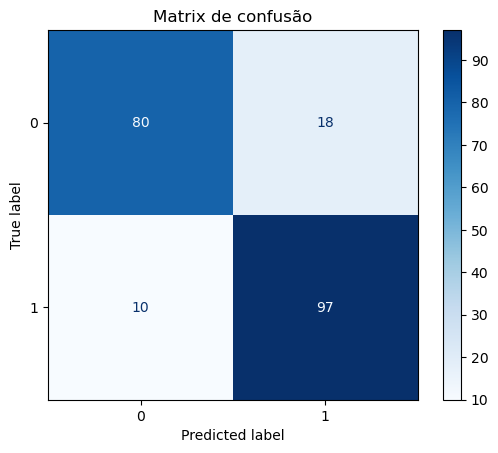

In [113]:
cm = confusion_matrix(Y_test, Y_pred)
matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
matrix.plot(cmap=plt.cm.Blues)
plt.title('Matrix de confusão')
plt.show()